# Impact of Modified Gravity $c_s^2$ on observables

In this Notebook, I test the impact of the MG-cs2 model on the cosmological observables.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import utils
from copy import deepcopy

matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
matplotlib.rcParams["legend.framealpha"] = 0.0

In [2]:
# Cosmological parameters for examples
H0 = 67
omegam = 0.319
omegab = 0.049
As = 2.1e-9
ns = 0.96
tau = 0.07

dark_energy_types = ["desi_pp_mean", "wcdm"]
dark_energy_type = "desi_pp_mean"

if dark_energy_type == "desi_pp_mean":
    # DESI DR2 BAO + CMB + Pantheon+ mean
    w0 = -0.838
    wa = -0.62
elif dark_energy_type == "wcdm":
    w0 = -0.8
    wa = 0
else:
    raise Exception(f"Unsupported dark_energy_type {dark_energy_type}; supported values are {dark_energy_types}.")

# Derived parameters
h = H0/100
omegac = omegam - omegab
ombh2 = omegab*h*h
omch2 = omegac*h*h

# k, z grid for power spectrum
ks = np.logspace(-4, -0.9, 256)
redshifts = np.linspace(0, 3, 256)

In [3]:
base_case = {"label": "GR", "use_cs2": False, "cs2_0": 1, "alpha_K_0": 1 }
cases1 = {
    "half": {"label": "$c_s^2 = 0.5$", "use_cs2": True,  "cs2_0": 0.5, "alpha_K_0": 1 },
    "one":  {"label": "$c_s^2 = 1$",   "use_cs2": True,  "cs2_0": 1,   "alpha_K_0": 1 },
    "two":  {"label": "$c_s^2 = 2$",   "use_cs2": True,  "cs2_0": 2,   "alpha_K_0": 1 },
}

cases2 = {
    "half": {"label": "$c_s^2 = 0.5$", "use_cs2": True,  "cs2_0": 0.5, "alpha_K_0": 3 },
    "one":  {"label": "$c_s^2 = 1$",   "use_cs2": True,  "cs2_0": 1,   "alpha_K_0": 3 },
    "two":  {"label": "$c_s^2 = 2$",   "use_cs2": True,  "cs2_0": 2,   "alpha_K_0": 3 },
}


utils.get_observables(base_case, H0, ombh2, omch2, As, ns, tau, w0, wa, dark_energy_type="ppf", alpha_k_parametrization=1, redshifts=redshifts, ks=ks)

for name, case in cases1.items():
    utils.get_observables(case, H0, ombh2, omch2, As, ns, tau, w0, wa, dark_energy_type="ppf", alpha_k_parametrization=1, redshifts=redshifts, ks=ks)
for name, case in cases2.items():
    utils.get_observables(case, H0, ombh2, omch2, As, ns, tau, w0, wa, dark_energy_type="ppf", alpha_k_parametrization=1, redshifts=redshifts, ks=ks)

cases1_prop = deepcopy(cases1)
for name, case in cases1_prop.items():
    utils.get_observables(case, H0, ombh2, omch2, As, ns, tau, w0, wa, dark_energy_type="ppf", alpha_k_parametrization=4, redshifts=redshifts, ks=ks)
cases2_prop = deepcopy(cases2)
for name, case in cases2_prop.items():
    utils.get_observables(case, H0, ombh2, omch2, As, ns, tau, w0, wa, dark_energy_type="ppf", alpha_k_parametrization=4, redshifts=redshifts, ks=ks)

cases1_cugal = deepcopy(cases1)
for name, case in cases1_cugal.items():
    utils.get_observables(case, H0, ombh2, omch2, As, ns, tau, w0, wa, dark_energy_type="ppf", alpha_k_parametrization=3, redshifts=redshifts, ks=ks)
cases2_cugal = deepcopy(cases2)
for name, case in cases2_cugal.items():
    utils.get_observables(case, H0, ombh2, omch2, As, ns, tau, w0, wa, dark_energy_type="ppf", alpha_k_parametrization=3, redshifts=redshifts, ks=ks)

cases1_kess = deepcopy(cases1)
for name, case in cases1_kess.items():
    utils.get_observables(case, H0, ombh2, omch2, As, ns, tau, w0, wa=-0.2, dark_energy_type="ppf", alpha_k_parametrization=2, redshifts=redshifts, ks=ks)
cases2_kess = deepcopy(cases2)
for name, case in cases2_kess.items():
    utils.get_observables(case, H0, ombh2, omch2, As, ns, tau, w0, wa=-0.2, dark_energy_type="ppf", alpha_k_parametrization=2, redshifts=redshifts, ks=ks)


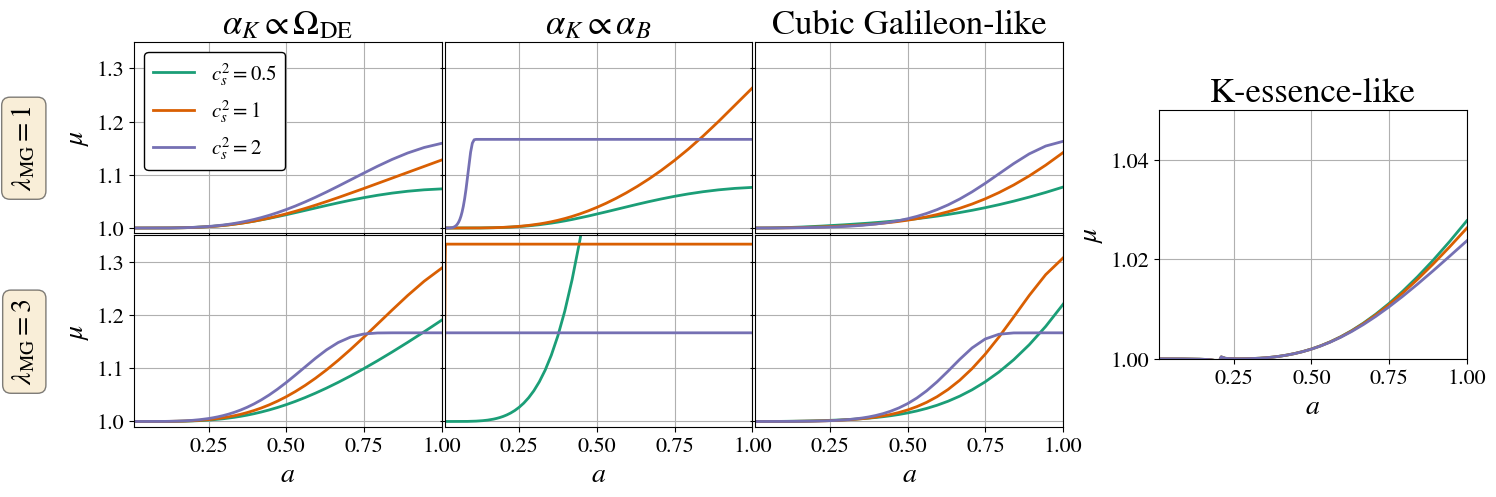

In [58]:
# Plot \mu(a)
# Generated from https://colorbrewer2.org/#type=sequential&scheme=OrRd&n=4
styles = [
    {"lw": 2, "color": "#1b9e77"},
    {"lw": 2, "color": "#d95f02"},
    {"lw": 2, "color": "#7570b3"},
]

# fig, axs = plt.subplots(2, 4, figsize=(16, 5), sharex=True, sharey=False, gridspec_kw={'hspace': 0.01, 'wspace': 0.01})

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 5))
gs = GridSpec(2, 4, figure=fig, hspace=0.01, wspace=0.01)

# First 3 columns: 2 rows x 3 cols
axs = [[fig.add_subplot(gs[i, j]) for j in range(3)] for i in range(2)]
# Last column: single tall panel spanning both rows
last_ax = fig.add_subplot(gs[:, 3])

for style, (name, case) in zip(styles, cases1.items()):
    a = np.exp(case["log_a"])
    axs[0][0].plot(a, case["mu"], label=case["label"], **style)

for style, (name, case) in zip(styles, cases2.items()):
    a = np.exp(case["log_a"])
    axs[1][0].plot(a, case["mu"], label=case["label"], **style)

for style, (name, case) in zip(styles, cases1_prop.items()):
    a = np.exp(case["log_a"])
    axs[0][1].plot(a, case["mu"], label=case["label"], **style)

for style, (name, case) in zip(styles, cases2_prop.items()):
    a = np.exp(case["log_a"])
    axs[1][1].plot(a, case["mu"], label=case["label"], **style)

for style, (name, case) in zip(styles, cases1_cugal.items()):
    a = np.exp(case["log_a"])
    axs[0][2].plot(a, case["mu"], label=case["label"], **style)

for style, (name, case) in zip(styles, cases2_cugal.items()):
    a = np.exp(case["log_a"])
    axs[1][2].plot(a, case["mu"], label=case["label"], **style)

for style, (name, case) in zip(styles, cases1_kess.items()):
    a = np.exp(case["log_a"])
    last_ax.plot(a, case["mu"], label=case["label"], **style)

axs[0][0].legend(fontsize=15, frameon=True, framealpha=1, edgecolor="black")
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
axs[0][0].text(-0.3, 1.15, "$\\lambda_\\mathrm{MG} = 1$", fontsize=20, ha="right", va="center", rotation=90, bbox=props)
axs[1][0].text(-0.3, 1.15, "$\\lambda_\\mathrm{MG} = 3$", fontsize=20, ha="right", va="center", rotation=90, bbox=props)
titles = ["$\\alpha_K \\propto \\Omega_\\mathrm{DE}$", "$\\alpha_K \\propto \\alpha_B$", "Cubic Galileon-like", "K-essence-like"]
flat_axes = [axs[0][0], axs[0][1], axs[0][2], last_ax,
             axs[1][0], axs[1][1], axs[1][2]]  # or arrange as you prefer
for i, ax in enumerate(flat_axes):
    if i%4 == 0: ax.set_ylabel("$\\mu$", fontsize=20)
    else: 
        if i != 3: ax.set_yticklabels([])
    if i < 4: 
        ax.set_title(titles[i], fontsize=25)
        if i != 3: ax.set_xticklabels([])
    else: ax.set_xlabel("$a$", fontsize=20)
    ax.set_xlim([1e-2, 1])
    ax.set_ylim([0.99, 1.35])
    ax.grid()
    ax.tick_params(axis='both', which='major', labelsize=16)

# ensure layout computed
fig.canvas.draw()

# reference single-row axis (top-left) and right-most single-row axis (top row, col 2)
pos_top = axs[0][0].get_position()
pos_third = axs[0][2].get_position()
pos_bottom = axs[1][0].get_position()

# match width/height to single-row axes
width = pos_third.width
height = pos_top.height*1.3

# vertical center between the two row centers
center_top = pos_top.y0 + 0.5 * pos_top.height
center_bottom = pos_bottom.y0 + 0.5 * pos_bottom.height
middle_center = 0.5 * (center_top + center_bottom)
new_y0 = middle_center - 0.5 * height

# horizontal position: a gap to the right of the 3rd column
gap = 0.06  # tweak this (0.02-0.06) to move it further right
new_x0 = pos_third.x1 + gap

# apply new position (x0, y0, width, height)
last_ax.set_position([new_x0, new_y0, width, height])
last_ax.set_ylim([1, 1.05])
last_ax.set_xlabel("$a$", fontsize=20)
last_ax.set_ylabel("$\\mu$", fontsize=20)

# re-draw and adjust ticks/legend as needed
fig.canvas.draw()

plt.savefig("plots/mg_cases_mu.pdf", bbox_inches="tight")

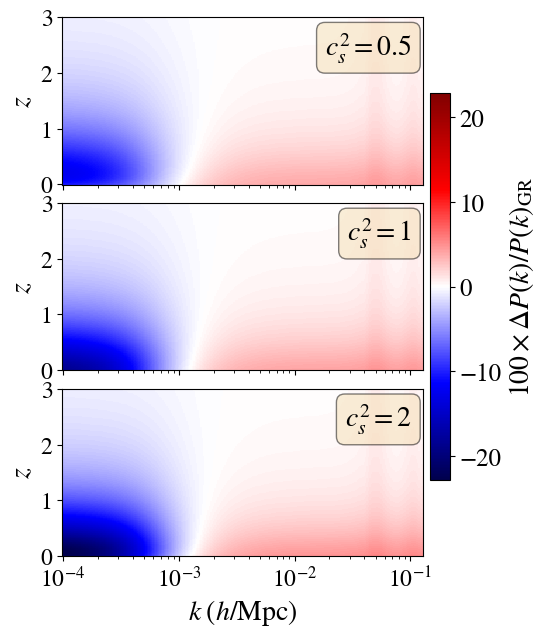

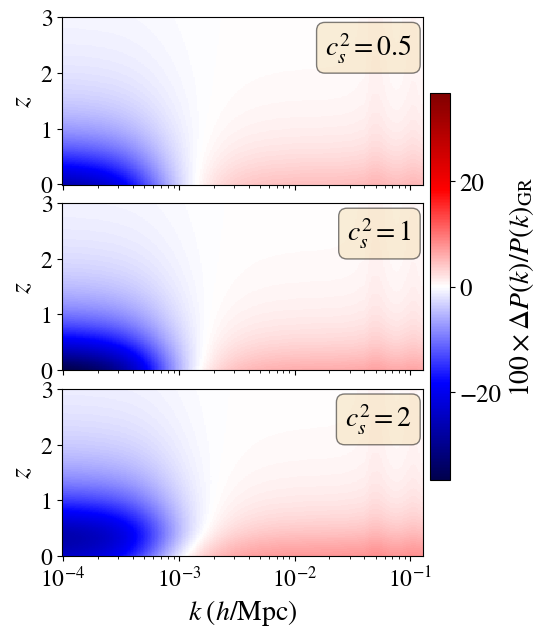

In [13]:
from importlib import reload
reload(utils)
utils.plot_pk_differences(cases1, base_case, ks, redshifts, "plots/impact_pk_mg_case1.png")
utils.plot_pk_differences(cases2, base_case, ks, redshifts, "plots/impact_pk_mg_case2.png")

/home/joao/cosmo/cs2-project/observables_impact/utils.py:66: RuntimeWarning: invalid value encountered in divide
  if name == "quint": continue
/home/joao/cosmo/cs2-project/observables_impact/utils.py:67: RuntimeWarning: invalid value encountered in divide
  axs[0, 0].semilogx(ells_tt, 100*(case["cl_tt"]/base_case["cl_tt"] - 1), label=case["label"], **style)
/home/joao/cosmo/cs2-project/observables_impact/utils.py:66: RuntimeWarning: invalid value encountered in divide
  if name == "quint": continue
/home/joao/cosmo/cs2-project/observables_impact/utils.py:67: RuntimeWarning: invalid value encountered in divide
  axs[0, 0].semilogx(ells_tt, 100*(case["cl_tt"]/base_case["cl_tt"] - 1), label=case["label"], **style)


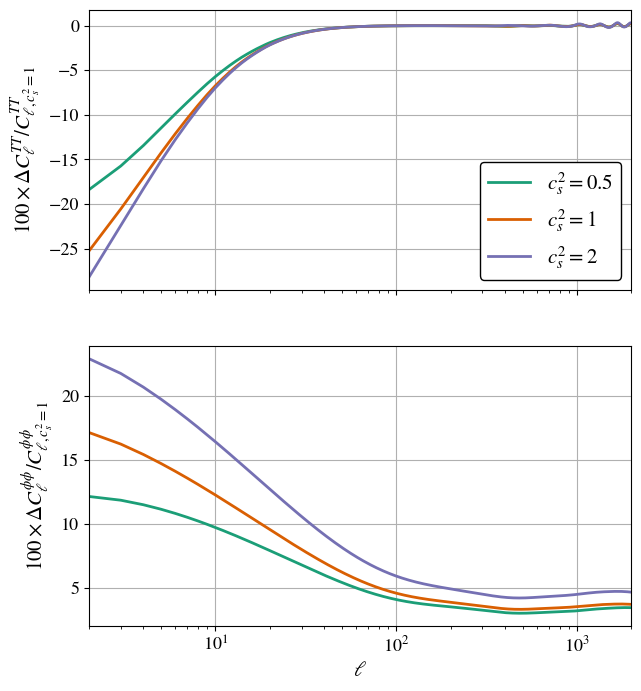

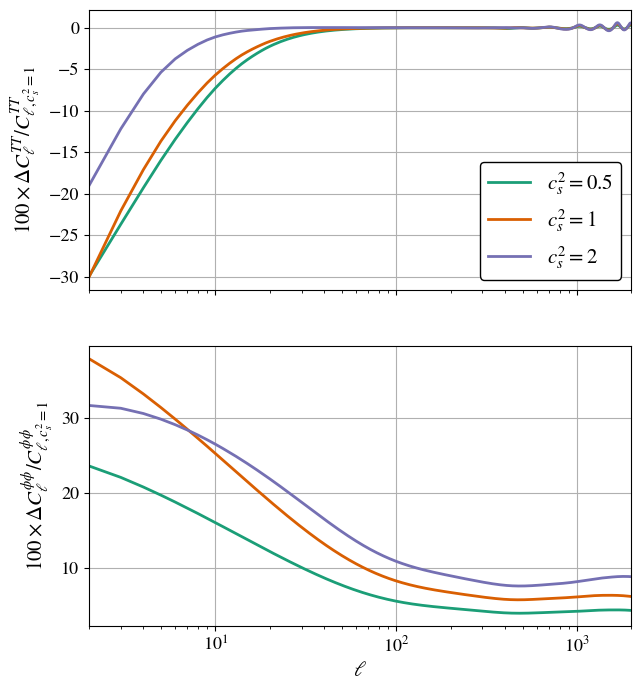

In [15]:
from importlib import reload
reload(utils)
utils.plot_cmb_differences(cases1, base_case, "plots/impact_cmb_mg_case1.pdf")
utils.plot_cmb_differences(cases2, base_case, "plots/impact_cmb_mg_case2.pdf")